In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Expected Period: 1.3927362637033918
Period Uncertainty: 0.0047140452079103175


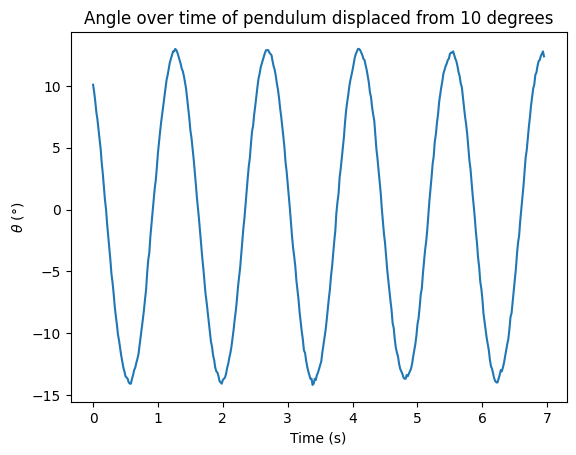

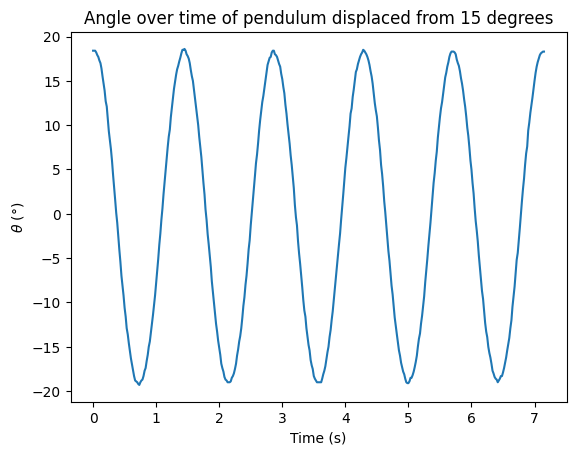

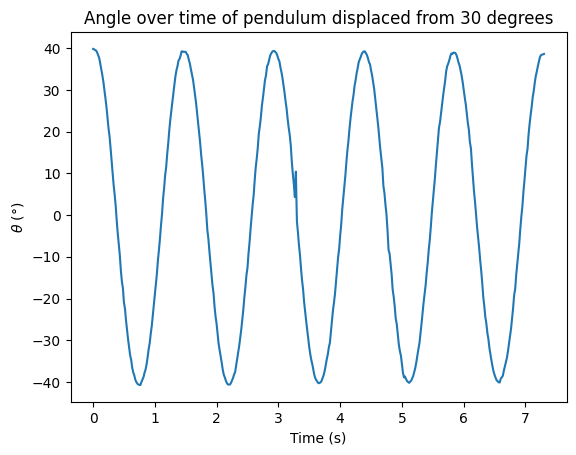

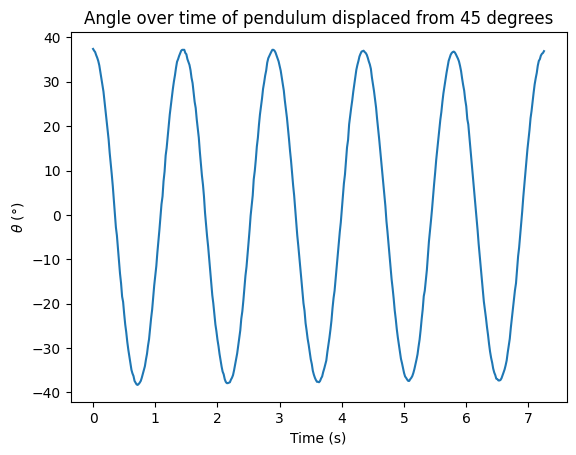

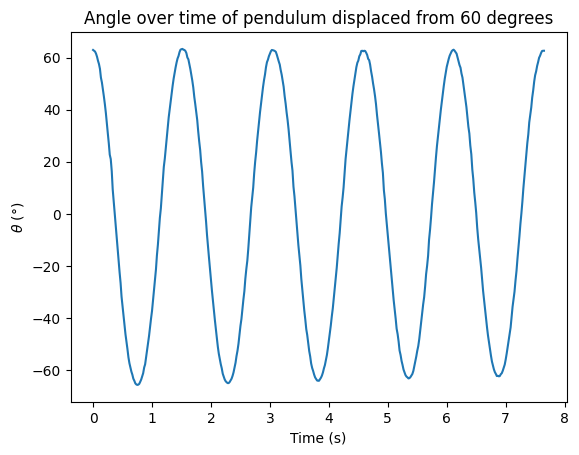

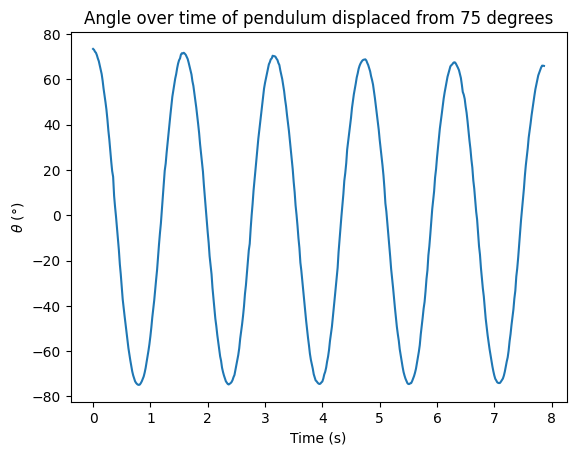

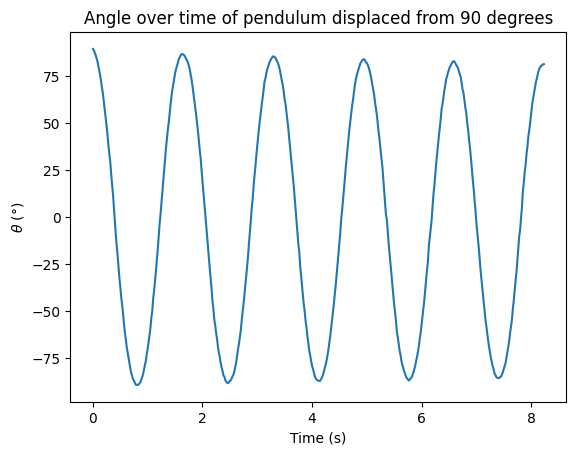

In [3]:
data10 = pd.read_csv("./data/3010_angle.txt", skiprows=1)
data15 = pd.read_csv("./data/3015_angle.txt", skiprows=1)
data30 = pd.read_csv("./data/3030_angle.txt", skiprows=1)
data45 = pd.read_csv("./data/3045_angle.txt", skiprows=1)
data60 = pd.read_csv("./data/3060_angle.txt", skiprows=1)
data75 = pd.read_csv("./data/3075_angle.txt", skiprows=1)
data90 = pd.read_csv("./data/3090_angle.txt", skiprows=1)
data10.Name = "10"
data15.Name = "15"
data30.Name = "30"
data45.Name = "45"
data60.Name = "60"
data75.Name = "75"
data90.Name = "90"

datasets = [data10, data15, data30, data45, data60, data75, data90]
# datasets = [data10]
m = 40 * 0.001 # kg
l = 48.2 * 0.01 # m
g = 9.81 # m / s^2
exp_period = 2 * np.pi * np.sqrt(l / g)

def cosine_func(x, amplitude, frequency, phase, offset):
    return amplitude * np.cos(frequency * x + phase) + offset

print(f"Expected Period: {exp_period}")

time_uncer = 1/60
period_uncer = np.sqrt(2 * (1/5)**2 * (time_uncer)**2)
print(f"Period Uncertainty: {period_uncer}")


for dataset in datasets:
    theta = np.array(dataset['θ'])
    rad = np.radians(theta)
    t = np.array(dataset['t'])
    num_oscillations = 5
    period = (t[-1] - t[0]) / num_oscillations
    err = (period - exp_period) / exp_period

    initial_guesses = [
        (np.max(rad) - np.min(rad)) / 2, # Amplitude guess
        num_oscillations-1,                # Frequency factor guess
        0,                               # Phase shift guess
        np.mean(rad)                     # Vertical shift guess
    ]

    popt, pcov = curve_fit(cosine_func, t, rad, p0=initial_guesses)
    fit_amplitude, fit_frequency, fit_phase, fit_offset = popt

    created_t = np.linspace(t[0], t[-1], len(t))
    created_theta = np.array([(cosine_func(t, fit_amplitude, fit_frequency, fit_phase, fit_offset)) for t in created_t])

    plt.plot(t, theta)
    init_angle = dataset.Name
    plt.title(f"Angle over time of pendulum displaced from {init_angle} degrees")
    plt.xlabel("Time (s)")
    plt.ylabel(r"$\theta$ ($\degree$)")
    # plt.plot(created_t, created_theta)
    plt.savefig(f"theta_time_plot_{init_angle}")
    plt.show()

    # print("Initial Fit Parameters:", initial_guesses)
    # print("Final Fit Parameters:", popt)
    # print("Initial Angle: ", x[0], rad[0]) 
    # print("Experimental Period: ", period, err)


In [4]:
def pendulum(
    alpha,
    omega,
    theta_0: float,
    omega_0: float,
    t_0: float,
    t_f: float,
    h: float = 0.001,
):
    n = np.round((t_f - t_0)/h).astype(int)
    t = np.linspace(t_0, t_f, n)

    v = np.zeros(n)
    x = np.zeros(n)
    v[0] = omega_0
    x[0] = theta_0

    for t_n in range(0, n - 1):
        k1_theta = h * omega(v[t_n])
        k1_omega = h * alpha(x[t_n], v[t_n])
        k2_theta = h * omega(v[t_n] + 0.5 * k1_omega)
        k2_omega = h * alpha(x[t_n] + 0.5 * k1_theta, v[t_n] + 0.5 * k1_omega)
        k3_theta = h * omega(v[t_n] + 0.5 * k2_omega)
        k3_omega = h * alpha(x[t_n] + 0.5 * k2_theta, v[t_n] + 0.5 * k2_omega)
        k4_theta = h * omega(v[t_n] + k3_omega)
        k4_omega = h * alpha(x[t_n] + k3_theta, v[t_n] + k3_omega)
        x[t_n + 1] = x[t_n] + (k1_theta + 2 * k2_theta + 2 * k3_theta + k4_theta) / 6
        v[t_n + 1] = v[t_n] + (k1_omega + 2 * k2_omega + 2 * k3_omega + k4_omega) / 6
    return t, x, v

[0.07485495 0.09590453 0.39009227 0.30610162 1.07967734 1.41138064
 1.61579005]
[0.07769256 0.07030588 0.13821083 0.0934048  0.1921976  0.2291989
 0.07978596]
[-0.0018474   0.01666574  0.16398488  0.13847412  0.57778475  0.76964753
  1.        ]
0.6424639941198376
[-43.08741483  23.1020566 ]


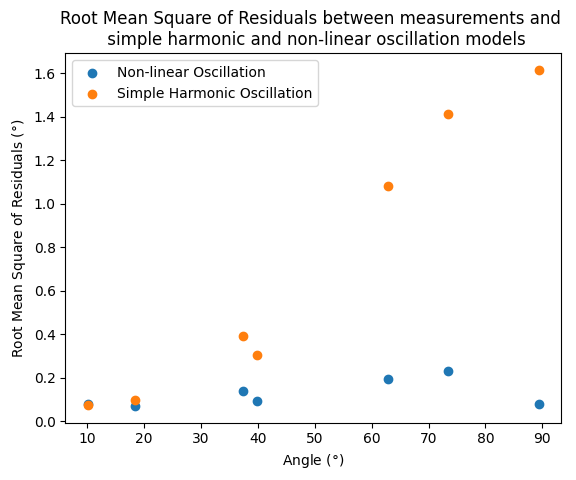

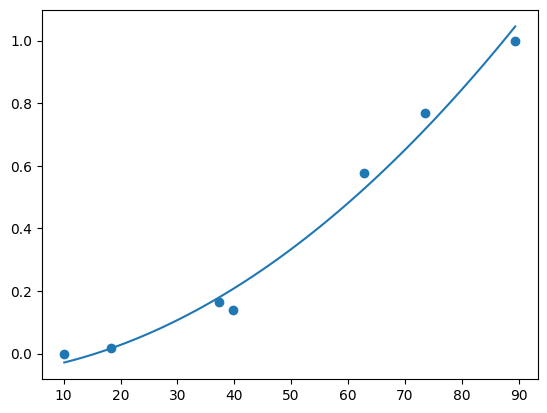

In [14]:
def a(theta, omega):
    g = 9.81
    L = 0.482
    return -(g / L) * np.sin(theta)

def a_shm(theta, omega):
    g = 9.81
    L = 0.482
    return -(g / L) * theta

def w(omega):
    return omega

residuals_pend = []
residuals_shm = []
initial_angles = []

exp_period = 2 * np.pi * np.sqrt(0.482 / 9.81)

for dataset in datasets:
    rad = np.array(np.radians(dataset['θ']))
    t = np.array(dataset['t'])
    theta_0 = rad[0]
    t2, rad2, v = pendulum(a, w, theta_0, 0, t[0], t[-1], h = t[-1]/len(t))
    t3, rad3, v2 = pendulum(a_shm, w, theta_0, 0, t[0], t[-1], h = t[-1]/len(t))

    ss_residual_shm = 0
    ss_residual_pend = 0
    for i in range(len(t)):
        ss_residual_shm += (rad[i] - rad3[i]) ** 2
        ss_residual_pend += (rad[i] - rad2[i]) ** 2

    residuals_pend.append(np.sqrt(ss_residual_pend/len(t)))
    residuals_shm.append(np.sqrt(ss_residual_shm/len(t)))
    initial_angles.append(theta_0)

    # plt.plot(t, rad, label="Experimental")
    # plt.plot(t2, rad2, label="Non-linear")
    # plt.plot(t3, rad3, label="Simple")
    # plt.title(f"Measured and simulated displacement angle over time for a pendulum displaced by {dataset.Name} degrees", fontsize=8)
    # plt.xlabel("Time (s)")
    # plt.ylabel(r"$\theta$ (rad)")
    # plt.legend()
    # plt.savefig(f"simulated_theta_time_plot_{dataset.Name}")
    # plt.show()

initial_angles = np.sort(np.rad2deg(initial_angles))
residuals_pend = np.array(residuals_pend)
residuals_shm = np.array(residuals_shm)
err = (residuals_shm - residuals_pend) / (residuals_shm[-1] - residuals_pend[-1])
err_uncer = np.sqrt((0.5**2) + (0.5**2) / (residuals_shm[-1] - residuals_pend[-1]))
print(residuals_shm)
print(residuals_pend)
print(err)
print(err_uncer)


coefficients = np.polyfit(initial_angles, err, 2)
polynomial_model = np.poly1d(coefficients)
created_x = np.linspace(initial_angles[0], initial_angles[-1], 100)
created_y = polynomial_model(created_x)

coefficients[-1] -= 0.05
print(np.roots(coefficients))

plt.Figure((600,400))
plt.scatter(initial_angles, residuals_pend, label="Non-linear Oscillation")
plt.scatter(initial_angles, residuals_shm, label="Simple Harmonic Oscillation")
plt.xlabel(r"Angle ($\degree$)")
plt.ylabel("Root Mean Square of Residuals ($\degree$)")
plt.title("Root Mean Square of Residuals between measurements and \n simple harmonic and non-linear oscillation models")
plt.legend()
plt.savefig("residual_plot")
plt.show()

plt.scatter(initial_angles, err)
plt.plot(created_x, created_y)
plt.show()

Err:  0.001964667521556239
Uncertainty in Err:  0.006501710785759723
Err:  0.026755773700845042
Uncertainty in Err:  0.00650401593442917
Err:  0.048296104617645844
Uncertainty in Err:  0.006505787155781201
Err:  0.041115994312045524
Uncertainty in Err:  0.006505192716570558
Err:  0.09855687675684809
Uncertainty in Err:  0.006510061024905374
Err:  0.12971855548315336
Uncertainty in Err:  0.006512809838032261
Err:  0.18242056512625976
Uncertainty in Err:  0.00651763091721423
[np.float64(1.3900000000000001), np.float64(1.4300000000000002), np.float64(1.46), np.float64(1.45), np.float64(1.53), np.float64(1.5734), np.float64(1.6468)]
[np.float64(0.001964667521556239), np.float64(0.026755773700845042), np.float64(0.048296104617645844), np.float64(0.041115994312045524), np.float64(0.09855687675684809), np.float64(0.12971855548315336), np.float64(0.18242056512625976)]
[np.float64(10.1), np.float64(18.400000000000002), np.float64(39.8), np.float64(37.4), np.float64(62.900000000000006), np.float

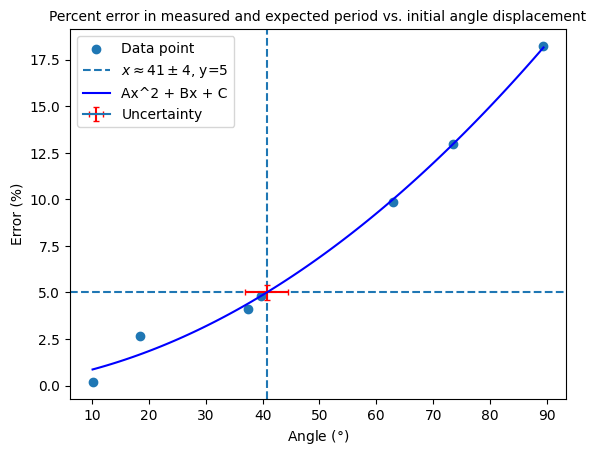

In [17]:
periods = []
period_err = []
initial_angles = []
errors = []


for dataset in datasets:
    theta = np.radians(np.array(dataset['θ']))
    t = np.array(dataset['t'])
    num_oscillations = 5
    period = (t[-1] - t[0]) / num_oscillations
    err = np.abs(period - exp_period) / exp_period
    exp_period_uncer = 2 * np.pi * np.sqrt(0.482 / 9.81)
    err_uncer = np.sqrt((1/exp_period_uncer)**2 * (0.009)**2 + (-period / (exp_period_uncer)**2)**2 * (0.001)**2)

    print("Err: ", err)
    print("Uncertainty in Err: ", err_uncer)

    initial_angles.append(np.rad2deg(theta[0]))
    periods.append(period)
    period_err.append(err)
    errors.append(err)

errors = np.array(errors)
errors *= 100

coefficients = np.polyfit(initial_angles, errors, 2)
polynomial_model = np.poly1d(coefficients)

created_x = np.linspace(initial_angles[0], initial_angles[-1], 100)
created_y = polynomial_model(created_x)

print(periods)
print(period_err)
print(initial_angles)

threshold_period = exp_period * 1.05

print("Threshold Period: ", threshold_period)
coeff = polynomial_model.coefficients
print(coeff)
coeff[-1] -= 5

threshold_angle = np.roots(coeff)[1]
angle_uncer = 0.7 / (2 * coeff[0] * threshold_angle + coeff[1])
print("x: ", threshold_angle)
print("Uncertainty in x: ", angle_uncer)


plt.scatter(initial_angles, errors, label="Data point")
plt.axvline(threshold_angle, linestyle="--")
plt.axhline(5, linestyle="--", label=r"$x \approx 41 \pm 4$, y=5")
plt.errorbar(threshold_angle, 5, yerr=0.4, xerr=angle_uncer, ecolor="red", capsize=2, label="Uncertainty")
plt.plot(created_x, created_y, label="Ax^2 + Bx + C", color="blue")
plt.xlabel(r"Angle ($\degree$)")
plt.ylabel("Error (%)")
plt.title("Percent error in measured and expected period vs. initial angle displacement", fontsize=10)
plt.legend()
plt.savefig("error_plot")
plt.show()





In [6]:
t = np.array(datasets[-1]["t"])
t = [f"{t:.2f}" for t in t]
theta10 = np.array(data10["θ"])
theta15 = np.array(data15["θ"])
theta30 = np.array(data30["θ"])
theta45 = np.array(data45["θ"])
theta60 = np.array(data60["θ"])
theta75 = np.array(data75["θ"])
theta90 = np.array(data90["θ"])

data = {'time': t, 'theta10': theta10, 'theta15': theta15, 'theta30': theta30, 'theta45': theta45, 'theta60': theta60, 'theta75': theta75, 'theta90': theta90}
df = pd.DataFrame(dict([(key, pd.Series(value)) for key, value in data.items()]))
print(df)
df.to_csv('data.csv', index=False)


     time  theta10  theta15  theta30  theta45  theta60  theta75  theta90
0    0.00     10.1     18.4     39.8     37.4     62.9     73.5     89.4
1    0.02      9.5     18.4     39.7     37.0     62.6     73.1     88.6
2    0.03      8.8     18.4     39.5     36.7     62.3     72.3     87.4
3    0.05      7.9     18.2     39.4     36.0     61.5     71.8     86.1
4    0.07      7.3     17.9     38.9     35.4     60.3     70.7     84.3
..    ...      ...      ...      ...      ...      ...      ...      ...
490  8.17      NaN      NaN      NaN      NaN      NaN      NaN     79.8
491  8.18      NaN      NaN      NaN      NaN      NaN      NaN     80.4
492  8.20      NaN      NaN      NaN      NaN      NaN      NaN     80.7
493  8.22      NaN      NaN      NaN      NaN      NaN      NaN     81.2
494  8.23      NaN      NaN      NaN      NaN      NaN      NaN     81.3

[495 rows x 8 columns]
